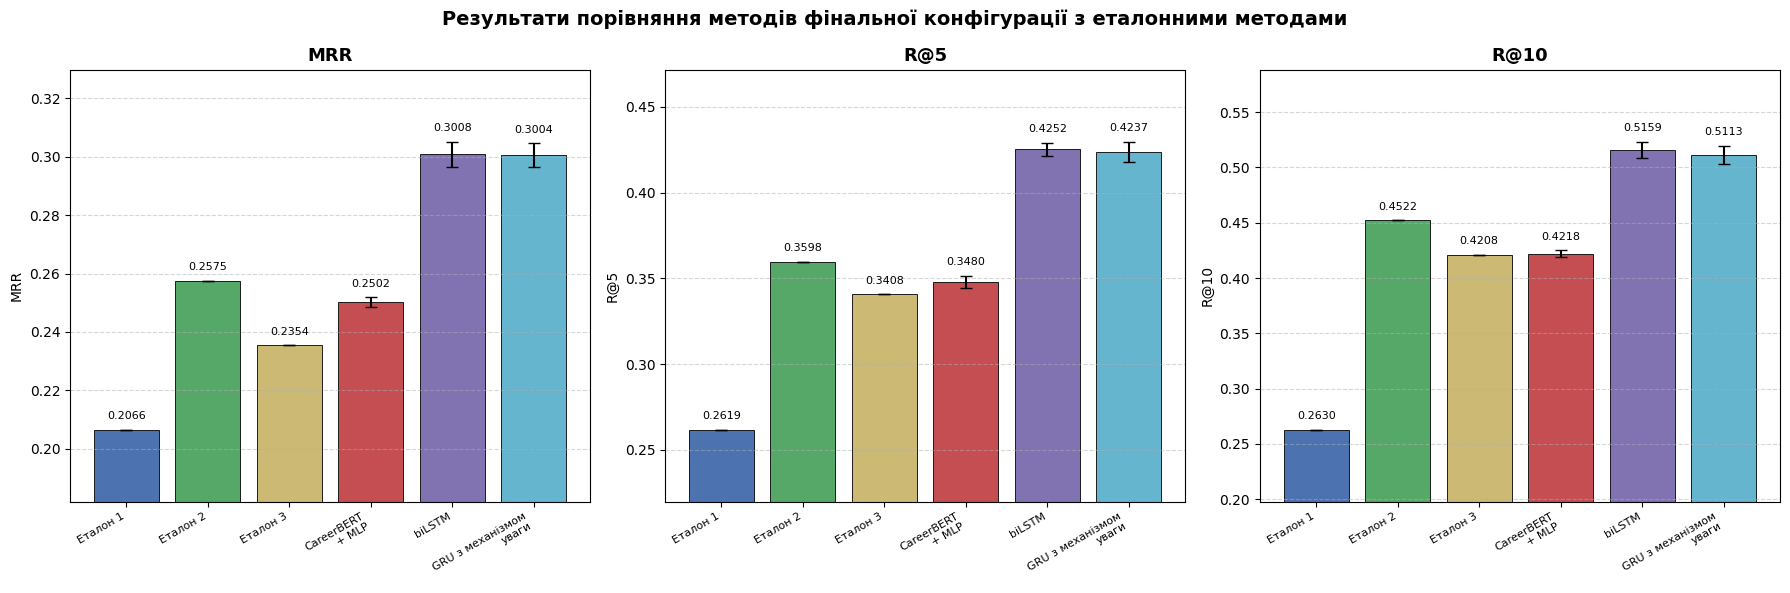

In [3]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Еталон 1', 'Еталон 2', 'Еталон 3', 'CareerBERT\n+ MLP',
          'biLSTM',
          'GRU з механізмом\nуваги']

mrr      = [0.2066, 0.2575, 0.2354, 0.2502, 0.3008, 0.3004]
mrr_err  = [0.0,    0.0,    0.0,    0.0017, 0.0043, 0.0041]

r5       = [0.2619, 0.3598, 0.3408, 0.3480, 0.4252, 0.4237]
r5_err   = [0.0,    0.0,    0.0,    0.0037, 0.0040, 0.0060]

r10      = [0.2630, 0.4522, 0.4208, 0.4218, 0.5159, 0.5113]
r10_err  = [0.0,    0.0,    0.0,    0.0032, 0.0073, 0.0080]

metrics = [('MRR', mrr, mrr_err),
           ('R@5', r5, r5_err),
           ('R@10', r10, r10_err)]

colors = ['#4C72B0', '#55A868', '#CCB974', '#C44E52', '#8172B2', '#64B5CD']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(models))

for ax, (name, vals, errs) in zip(axes, metrics):
    bars = ax.bar(x, vals, yerr=errs, capsize=4, color=colors,
                  edgecolor='black', linewidth=0.6)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(name)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    lo = min(v - e for v, e in zip(vals, errs))
    hi = max(v + e for v, e in zip(vals, errs))
    pad = (hi - lo) * 0.25
    ax.set_ylim(lo - pad, hi + pad)

    for bar, v, e in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + e + (hi - lo) * 0.03,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Результати порівняння методів фінальної конфігурації з еталонними методами',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()